# Tugas 3 CNN - Kelompok 8
## Klasifikasi Kondisi Cuaca Menggunakan CNN

### Muhammad Nazlul Ramadhyan (2308107010036)
### Naufal Farrel Syafilan (2308107010058)


Notebook ini digunakan untuk membangun model klasifikasi gambar cuaca menggunakan metode **Convolutional Neural Network (CNN)**.

Dataset yang digunakan adalah **Multi-class Weather Dataset** dari Kaggle: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset. Dataset aslinya memiliki 4 kelas, yaitu:

- `Cloudy`
- `Rain`
- `Shine`
- `Sunrise`

Pada tugas ini hanya digunakan **3 kelas** agar sesuai dengan ketentuan tugas, yaitu maksimal 3 kelas. Kelas yang dipakai adalah:

- `Cloudy`
- `Rain`
- `Shine`

Kelas `Sunrise` tidak digunakan karena tugas hanya membutuhkan maksimal 3 kelas. Setiap kelas juga dibatasi menjadi **200 gambar**, sehingga total data yang digunakan adalah **600 gambar**.

## 1. Import Library

Bagian ini berisi library yang digunakan untuk membaca data, mengolah gambar, membangun model CNN, dan melakukan evaluasi.

In [1]:
import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Pengaturan Awal

Nilai `SEED` digunakan agar proses pengacakan data lebih konsisten saat notebook dijalankan ulang.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ukuran gambar yang akan digunakan oleh model
IMG_SIZE = (150, 150)

# Kelas yang dipakai dalam tugas
SELECTED_CLASSES = ["cloudy", "rain", "shine"]

# Jumlah gambar per kelas
MAX_IMAGES_PER_CLASS = 200

# Rasio pembagian data
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

## 3. Membaca dan Mengekstrak File ZIP

Upload file dataset `.zip` ke Google Colab, lalu pastikan file tersebut ada di panel **Files**.

Pada contoh ini nama file zip adalah:

```text
archive (25).zip
```

Jika nama file zip berbeda, ubah bagian `ZIP_FILE` sesuai nama file yang ada di Colab.

In [3]:
# Lokasi file zip di Google Colab
ZIP_FILE = Path("/content/WeatherDataset.zip")

# Folder hasil ekstrak
EXTRACT_DIR = Path("/content/weather_dataset_raw")

# Jika nama ZIP berbeda, kode ini akan mencoba mencari file .zip lain di /content
if not ZIP_FILE.exists():
    zip_candidates = sorted(Path("/content").glob("*.zip"), key=lambda x: x.stat().st_mtime, reverse=True)

    if len(zip_candidates) == 0:
        raise FileNotFoundError(
            "File ZIP tidak ditemukan. Upload dataset .zip ke Colab terlebih dahulu."
        )

    ZIP_FILE = zip_candidates[0]
    print("File ZIP yang digunakan:", ZIP_FILE)

# Hapus folder ekstrak lama agar hasilnya bersih
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Ekstrak file ZIP
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset berhasil diekstrak ke:", EXTRACT_DIR)

Dataset berhasil diekstrak ke: /content/weather_dataset_raw


## 4. Mengecek Struktur Folder Dataset

Setelah file zip diekstrak, struktur folder perlu dicek terlebih dahulu. Hal ini penting karena struktur folder hasil ekstrak kadang berbeda-beda tergantung dari dataset yang diunduh.

In [4]:
# Menampilkan sebagian struktur folder hasil ekstrak
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(str(EXTRACT_DIR), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{Path(root).name}/")

    sub_indent = " " * 4 * (level + 1)
    for file in files[:5]:
        print(f"{sub_indent}{file}")

weather_dataset_raw/
    Multi-class Weather Dataset/
        Cloudy/
            cloudy248.jpg
            cloudy15.jpg
            cloudy54.jpg
            cloudy157.jpg
            cloudy93.jpg
        Sunrise/
            sunrise316.jpg
            sunrise243.jpg
            sunrise26.jpg
            sunrise150.jpg
            sunrise172.jpg
        Rain/
            rain171.jpg
            rain34.jpg
            rain77.jpg
            rain67.jpg
            rain187.jpg
        Shine/
            shine49.jpg
            shine72.jpg
            shine148.jpg
            shine73.jpg
            shine40.jpg


## 5. Mengambil 3 Kelas dan Membatasi 200 Gambar per Kelas

Dataset aslinya memiliki kelas `Sunrise`, tetapi pada tugas ini kelas tersebut tidak digunakan.

Bagian kode berikut akan mencari folder kelas `cloudy`, `rain`, dan `shine`, lalu menyalin masing-masing **200 gambar** ke folder baru.

In [5]:
def find_class_folder(root_dir, class_name):
    # Mencari folder kelas berdasarkan nama folder.
    # Pencarian dibuat tidak sensitif terhadap huruf besar/kecil.
    matches = []

    for folder in root_dir.rglob("*"):
        if folder.is_dir() and folder.name.lower() == class_name.lower():
            matches.append(folder)

    if len(matches) == 0:
        raise FileNotFoundError(f"Folder kelas '{class_name}' tidak ditemukan di {root_dir}")

    return matches[0]


def get_valid_image_files(folder):
    # Mengambil file gambar yang valid dari sebuah folder.
    allowed_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    image_files = [
        file for file in folder.glob("*")
        if file.is_file() and file.suffix.lower() in allowed_extensions
    ]

    valid_files = []

    for file in image_files:
        try:
            with Image.open(file) as img:
                img.verify()
            valid_files.append(file)
        except Exception:
            print("File rusak atau tidak bisa dibaca:", file)

    return valid_files


# Folder dataset baru yang hanya berisi 3 kelas dan 200 gambar per kelas
LIMITED_DATASET_DIR = Path("/content/weather_dataset_3kelas_200")

if LIMITED_DATASET_DIR.exists():
    shutil.rmtree(LIMITED_DATASET_DIR)

LIMITED_DATASET_DIR.mkdir(parents=True, exist_ok=True)

class_source_folders = {}

for class_name in SELECTED_CLASSES:
    class_folder = find_class_folder(EXTRACT_DIR, class_name)
    class_source_folders[class_name] = class_folder

    image_files = get_valid_image_files(class_folder)

    if len(image_files) < MAX_IMAGES_PER_CLASS:
        raise ValueError(
            f"Kelas '{class_name}' hanya memiliki {len(image_files)} gambar. "
            f"Minimal dibutuhkan {MAX_IMAGES_PER_CLASS} gambar."
        )

    random.shuffle(image_files)
    selected_images = image_files[:MAX_IMAGES_PER_CLASS]

    target_class_dir = LIMITED_DATASET_DIR / class_name
    target_class_dir.mkdir(parents=True, exist_ok=True)

    for image_path in selected_images:
        shutil.copy2(image_path, target_class_dir / image_path.name)

    print(f"{class_name}: {len(selected_images)} gambar disalin dari {class_folder}")

print("\nDataset terbatas sudah dibuat di:", LIMITED_DATASET_DIR)

cloudy: 200 gambar disalin dari /content/weather_dataset_raw/Multi-class Weather Dataset/Cloudy
rain: 200 gambar disalin dari /content/weather_dataset_raw/Multi-class Weather Dataset/Rain
shine: 200 gambar disalin dari /content/weather_dataset_raw/Multi-class Weather Dataset/Shine

Dataset terbatas sudah dibuat di: /content/weather_dataset_3kelas_200


## 6. Mengecek Jumlah Data

Bagian ini digunakan untuk memastikan bahwa setiap kelas sudah berisi 200 gambar.

In [6]:
class_counts = []

for class_name in SELECTED_CLASSES:
    class_dir = LIMITED_DATASET_DIR / class_name
    total_images = len([
        file for file in class_dir.glob("*")
        if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])

    class_counts.append({
        "Kelas": class_name,
        "Jumlah Gambar": total_images
    })

class_counts_df = pd.DataFrame(class_counts)
display(class_counts_df)

print("Total gambar:", class_counts_df["Jumlah Gambar"].sum())

,Kelas,Jumlah Gambar
0,cloudy,200
1,rain,200
2,shine,200


Total gambar: 600


## 7. Visualisasi Contoh Gambar

Beberapa contoh gambar ditampilkan agar isi dataset dapat dilihat sebelum masuk ke tahap training.

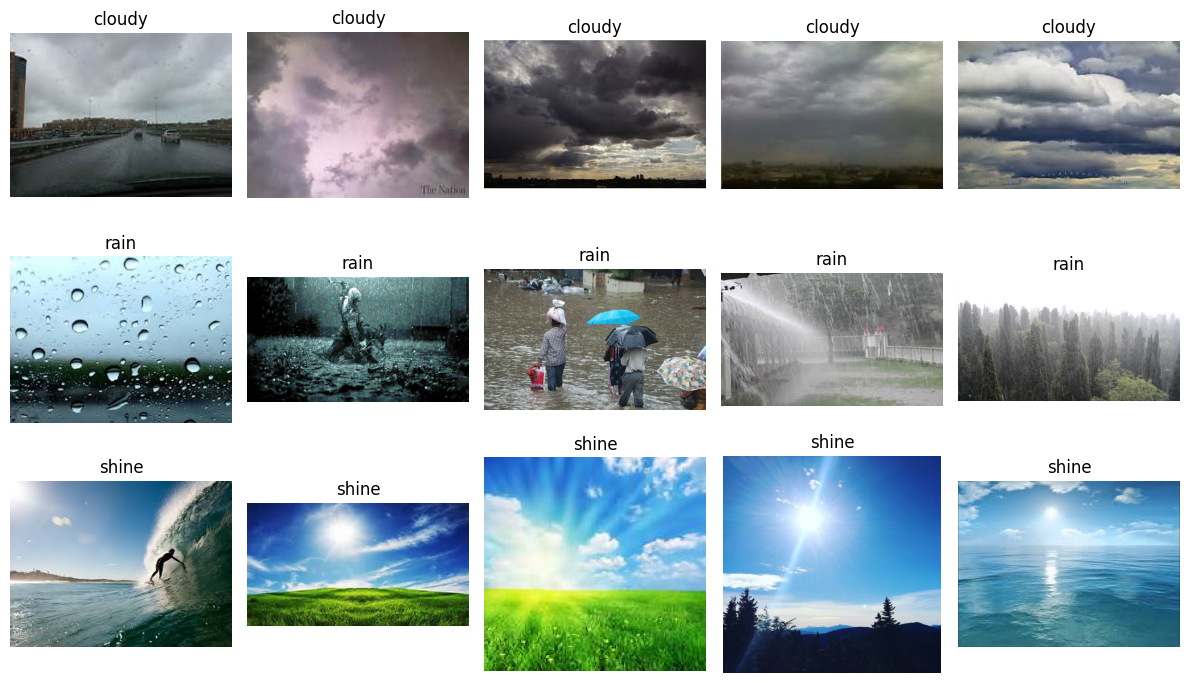

In [7]:
plt.figure(figsize=(12, 7))

plot_index = 1

for class_name in SELECTED_CLASSES:
    class_dir = LIMITED_DATASET_DIR / class_name
    image_files = list(class_dir.glob("*"))
    sample_images = random.sample(image_files, 5)

    for image_path in sample_images:
        img = Image.open(image_path).convert("RGB")

        plt.subplot(len(SELECTED_CLASSES), 5, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

## 8. Splitting Data

Data dibagi menjadi tiga bagian:

- **70% data latih**
- **15% data validasi**
- **15% data uji**

Karena setiap kelas berisi 200 gambar, maka pembagiannya menjadi:

- Train: 140 gambar per kelas
- Validation: 30 gambar per kelas
- Test: 30 gambar per kelas

In [8]:
SPLIT_DATASET_DIR = Path("/content/weather_dataset_split")

if SPLIT_DATASET_DIR.exists():
    shutil.rmtree(SPLIT_DATASET_DIR)

for split_name in ["train", "val", "test"]:
    for class_name in SELECTED_CLASSES:
        (SPLIT_DATASET_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)


def copy_files(file_list, target_folder):
    target_folder.mkdir(parents=True, exist_ok=True)

    for file_path in file_list:
        shutil.copy2(file_path, target_folder / file_path.name)


for class_name in SELECTED_CLASSES:
    class_dir = LIMITED_DATASET_DIR / class_name
    image_files = list(class_dir.glob("*"))

    train_files, temp_files = train_test_split(
        image_files,
        train_size=TRAIN_RATIO,
        random_state=SEED,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=SEED,
        shuffle=True
    )

    copy_files(train_files, SPLIT_DATASET_DIR / "train" / class_name)
    copy_files(val_files, SPLIT_DATASET_DIR / "val" / class_name)
    copy_files(test_files, SPLIT_DATASET_DIR / "test" / class_name)

print("Splitting data selesai.")
print("Folder dataset split:", SPLIT_DATASET_DIR)

Splitting data selesai.
Folder dataset split: /content/weather_dataset_split


In [9]:
split_counts = []

for split_name in ["train", "val", "test"]:
    for class_name in SELECTED_CLASSES:
        class_dir = SPLIT_DATASET_DIR / split_name / class_name
        total_images = len([
            file for file in class_dir.glob("*")
            if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
        ])

        split_counts.append({
            "Split": split_name,
            "Kelas": class_name,
            "Jumlah Gambar": total_images
        })

split_counts_df = pd.DataFrame(split_counts)
display(split_counts_df)

summary_split_df = split_counts_df.pivot(index="Kelas", columns="Split", values="Jumlah Gambar")
display(summary_split_df)

,Split,Kelas,Jumlah Gambar
0,train,cloudy,140
1,train,rain,140
2,train,shine,140
3,val,cloudy,30
4,val,rain,30
5,val,shine,30
6,test,cloudy,30
7,test,rain,30
8,test,shine,30


Split,test,train,val
Kelas,,,
cloudy,30,140,30
rain,30,140,30
shine,30,140,30


## 9. Preprocessing Data

Preprocessing yang dilakukan pada gambar:

1. Gambar diubah ukurannya menjadi `150 x 150` piksel.
2. Data dibaca menggunakan `image_dataset_from_directory`.
3. Nilai piksel akan dinormalisasi pada bagian model menggunakan layer `Rescaling(1./255)`.
4. Dataset dibuat lebih efisien menggunakan `cache()` dan `prefetch()`.

Label gambar dibuat otomatis berdasarkan nama folder kelas.

In [10]:
TRAIN_DIR = SPLIT_DATASET_DIR / "train"
VAL_DIR = SPLIT_DATASET_DIR / "val"
TEST_DIR = SPLIT_DATASET_DIR / "test"

AUTOTUNE = tf.data.AUTOTUNE


def load_datasets(batch_size):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode="int",
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode="int",
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode="int",
        shuffle=False
    )

    class_names = train_ds.class_names

    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names


# Dataset awal dengan batch size 32
train_ds, val_ds, test_ds, class_names = load_datasets(batch_size=32)

print("Nama kelas:", class_names)

Found 420 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Nama kelas: ['cloudy', 'rain', 'shine']


## 10. Konfigurasi Model

Pada tugas ini dibuat 3 model CNN dengan konfigurasi yang berbeda.

| Model | Konfigurasi Utama |
|---|---|
| Model 1 | CNN sederhana, 2 convolution layer |
| Model 2 | CNN lebih dalam, menggunakan Dropout |
| Model 3 | CNN dengan Data Augmentation, Batch Normalization, dan Dropout |

Perbandingan ini dilakukan untuk melihat pengaruh perubahan arsitektur dan hyperparameter terhadap hasil klasifikasi.

In [11]:
NUM_CLASSES = len(SELECTED_CLASSES)
INPUT_SHAPE = IMG_SIZE + (3,)


def build_model_1(learning_rate=0.001):
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_model_2(learning_rate=0.001):
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_model_3(learning_rate=0.0005):
    data_augmentation = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 11. Ringkasan Arsitektur Model

Sebelum training, ringkasan model ditampilkan untuk melihat susunan layer dan jumlah parameter.

In [12]:
model_1_preview = build_model_1()
model_2_preview = build_model_2()
model_3_preview = build_model_3()

print("MODEL 1")
model_1_preview.summary()

print("\nMODEL 2")
model_2_preview.summary()

print("\nMODEL 3")
model_3_preview.summary()

MODEL 1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,739 (40.58 MB)

 Trainable params: 10,636,739 (40.58 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

## 12. Fungsi Training dan Evaluasi

Fungsi berikut dibuat agar proses training dan evaluasi setiap model lebih rapi. Evaluasi dilakukan menggunakan:

- Accuracy
- Precision
- Recall
- F1-score

Nilai precision, recall, dan f1-score dihitung dengan rata-rata **macro average**, sehingga setiap kelas memiliki bobot yang sama.

In [13]:
def get_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_labels)

    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, test_dataset, class_names):
    y_true, y_pred = get_predictions(model, test_dataset)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    return accuracy, precision, recall, f1, report, y_true, y_pred


def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Akurasi - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

## 13. Training Beberapa Model CNN

Tiga model dilatih dengan konfigurasi berbeda. Early stopping digunakan agar training berhenti jika performa validasi tidak membaik.

Training: Model 1 - CNN Dasar
Found 420 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4238 - loss: 2.0491 - val_accuracy: 0.7333 - val_loss: 0.7589 - learning_rate: 0.0010
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7286 - loss: 0.7059 - val_accuracy: 0.6889 - val_loss: 0.7081 - learning_rate: 0.0010
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7690 - loss: 0.5469 - val_accuracy: 0.7333 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8571 - loss: 0.3640 - val_accuracy: 0.7556 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8333 - loss: 0.3881 - val_accuracy: 0.8333 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9048 - loss: 0.2718 - val_accuracy: 0.

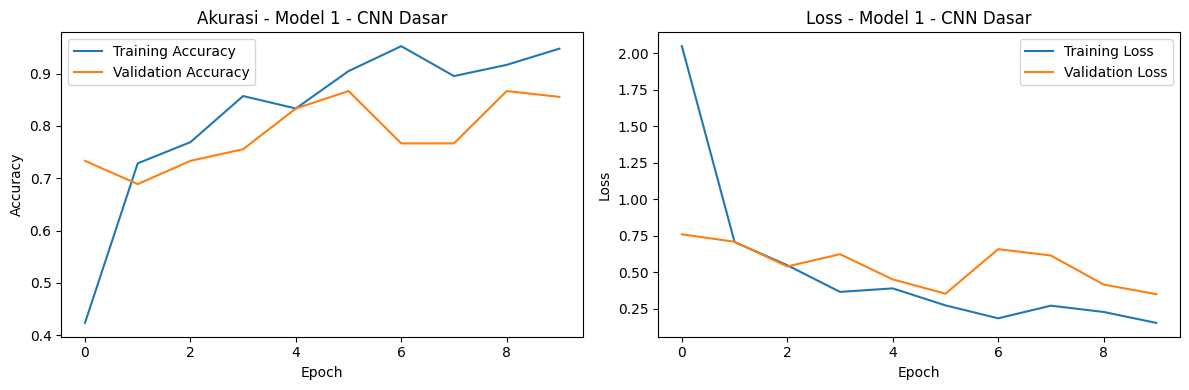

Training: Model 2 - CNN Dropout
Found 420 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Epoch 1/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4952 - loss: 1.0623 - val_accuracy: 0.5222 - val_loss: 0.9976 - learning_rate: 0.0010
Epoch 2/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6786 - loss: 0.7692 - val_accuracy: 0.8333 - val_loss: 0.5992 - learning_rate: 0.0010
Epoch 3/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8024 - loss: 0.5473 - val_accuracy: 0.7778 - val_loss: 0.5461 - learning_rate: 0.0010
Epoch 4/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8714 - loss: 0.3505 - val_accuracy: 0.9333 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 5/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8976 - loss: 0.2401 - val_accuracy: 0.8667 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 6/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8524 - loss: 0.4022 - val_accuracy: 

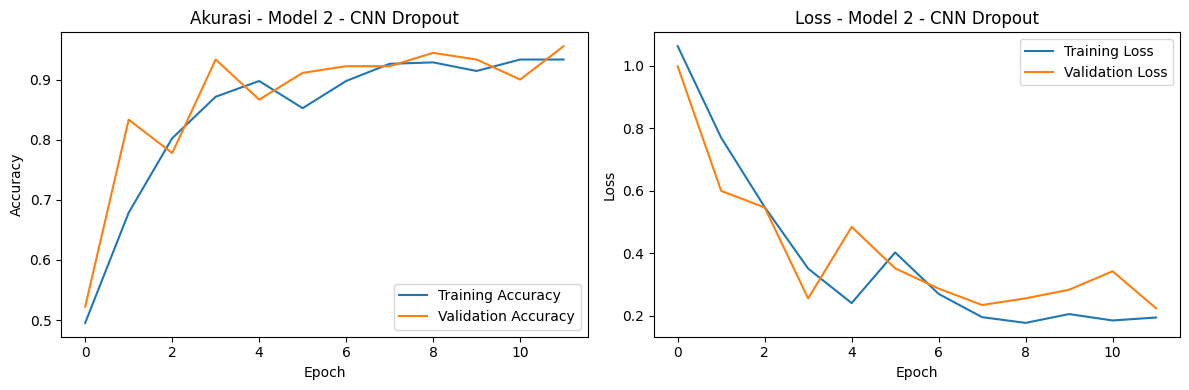

Training: Model 3 - CNN Augmentation
Found 420 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.6143 - loss: 0.8542 - val_accuracy: 0.3333 - val_loss: 1.0815 - learning_rate: 5.0000e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.7952 - loss: 0.5520 - val_accuracy: 0.3333 - val_loss: 1.0789 - learning_rate: 5.0000e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.8071 - loss: 0.4704 - val_accuracy: 0.3556 - val_loss: 1.0833 - learning_rate: 5.0000e-04
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8381 - loss: 0.3736 - val_accuracy: 0.3667 - val_loss: 1.0783 - learning_rate: 5.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8786 - loss: 0.3405 - val_accuracy: 0.3778 - val_loss: 1.0704 - learning_rate: 5.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.8786 - loss: 0.3272 - v


Classification Report:
              precision    recall  f1-score   support

      cloudy       0.33      0.07      0.11        30
        rain       0.44      1.00      0.61        30
       shine       1.00      0.53      0.70        30

    accuracy                           0.53        90
   macro avg       0.59      0.53      0.47        90
weighted avg       0.59      0.53      0.47        90



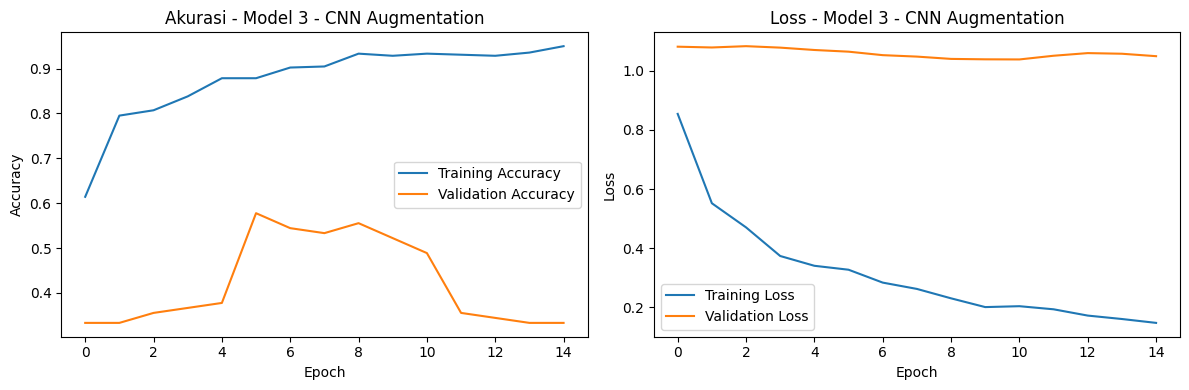

In [14]:
experiments = [
    {
        "name": "Model 1 - CNN Dasar",
        "builder": build_model_1,
        "epochs": 10,
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "name": "Model 2 - CNN Dropout",
        "builder": build_model_2,
        "epochs": 12,
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "name": "Model 3 - CNN Augmentation",
        "builder": build_model_3,
        "epochs": 15,
        "batch_size": 64,
        "learning_rate": 0.0005
    }
]

results = []
histories = {}
trained_models = {}
prediction_results = {}

for experiment in experiments:
    print("=" * 80)
    print("Training:", experiment["name"])
    print("=" * 80)

    tf.keras.backend.clear_session()

    train_ds_exp, val_ds_exp, test_ds_exp, class_names_exp = load_datasets(
        batch_size=experiment["batch_size"]
    )

    model = experiment["builder"](learning_rate=experiment["learning_rate"])

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds_exp,
        validation_data=val_ds_exp,
        epochs=experiment["epochs"],
        callbacks=callbacks,
        verbose=1
    )

    accuracy, precision, recall, f1, report, y_true, y_pred = evaluate_model(
        model,
        test_ds_exp,
        class_names_exp
    )

    results.append({
        "Model": experiment["name"],
        "Batch Size": experiment["batch_size"],
        "Learning Rate": experiment["learning_rate"],
        "Epoch Maksimal": experiment["epochs"],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    histories[experiment["name"]] = history
    trained_models[experiment["name"]] = model
    prediction_results[experiment["name"]] = {
        "y_true": y_true,
        "y_pred": y_pred
    }

    print("\nClassification Report:")
    print(report)

    plot_training_history(history, experiment["name"])

## 14. Perbandingan Hasil Evaluasi

Tabel berikut menampilkan perbandingan hasil evaluasi dari semua model yang telah dilatih.

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Batch Size,Learning Rate,Epoch Maksimal,Accuracy,Precision,Recall,F1-score
0,Model 2 - CNN Dropout,32,0.0010,12,0.911111,0.912387,0.911111,0.910619
1,Model 1 - CNN Dasar,32,0.0010,10,0.855556,0.881410,0.855556,0.849434
2,Model 3 - CNN Augmentation,64,0.0005,15,0.533333,0.591503,0.533333,0.473003


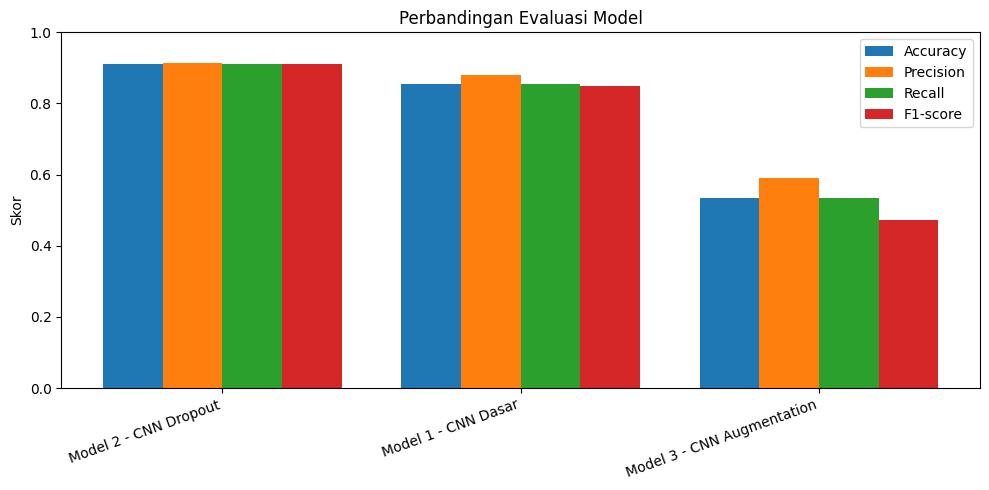

In [16]:
plt.figure(figsize=(10, 5))

x = np.arange(len(results_df["Model"]))
width = 0.2

plt.bar(x - 1.5 * width, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, results_df["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, results_df["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, results_df["F1-score"], width, label="F1-score")

plt.xticks(x, results_df["Model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Skor")
plt.title("Perbandingan Evaluasi Model")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretasi Perbandingan Model

Berdasarkan hasil evaluasi pada data test, **Model 2 - CNN Dropout** menjadi model terbaik dengan nilai **accuracy 0.9111**, **precision 0.9124**, **recall 0.9111**, dan **F1-score 0.9106**. Nilai ini menunjukkan bahwa model mampu mengklasifikasikan gambar cuaca dengan cukup baik dan performanya seimbang pada ketiga kelas.

**Model 1 - CNN Dasar** memperoleh hasil yang sedikit lebih rendah, yaitu **accuracy 0.8556**, **precision 0.8814**, **recall 0.8556**, dan **F1-score 0.8494**. Meskipun arsitekturnya lebih sederhana, model ini tetap menunjukkan performa yang cukup baik dalam mengklasifikasikan kondisi cuaca.

**Model 3 - CNN Augmentation** memperoleh nilai paling rendah, yaitu **accuracy 0.5333** dan **F1-score 0.4730**. Model ini menggunakan data augmentation dan batch normalization, tetapi pada percobaan ini hasilnya belum optimal. Kemungkinan penyebabnya adalah konfigurasi augmentation, learning rate, atau jumlah epoch yang belum sesuai untuk dataset ini.

Dari perbandingan tersebut, **Model 2 - CNN Dropout** memberikan hasil terbaik pada dataset cuaca yang digunakan. Penggunaan dropout terbukti membantu model menggeneralisasi dengan lebih baik. Oleh karena itu, model yang disimpan adalah **Model 2 - CNN Dropout** karena memiliki F1-score tertinggi.


## 15. Confusion Matrix Model Terbaik

Model terbaik dipilih berdasarkan nilai **F1-score** tertinggi. Confusion matrix digunakan untuk melihat kelas mana yang sudah diklasifikasikan dengan baik dan kelas mana yang masih sering tertukar.

Model terbaik: Model 2 - CNN Dropout


<Figure size 600x600 with 0 Axes>

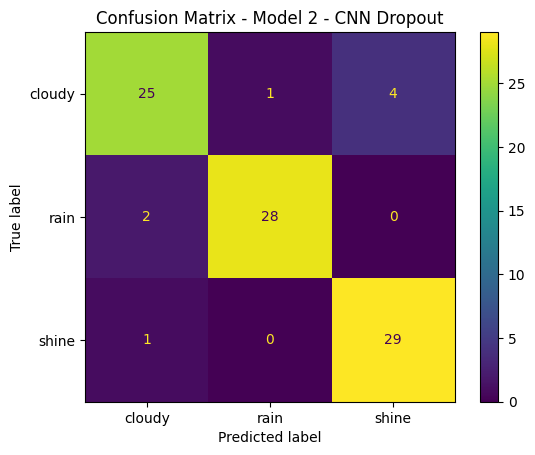

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_y_true = prediction_results[best_model_name]["y_true"]
best_y_pred = prediction_results[best_model_name]["y_pred"]

print("Model terbaik:", best_model_name)

cm = confusion_matrix(best_y_true, best_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6, 6))
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 16. Menyimpan Model ke Format `.h5`

Sesuai ketentuan tugas, model yang telah dibangun disimpan dalam format `.h5`.

Model yang disimpan adalah model dengan nilai F1-score tertinggi.

Catatan: Jika muncul peringatan bahwa format HDF5 (`.h5`) bersifat legacy, peringatan tersebut bukan error. Format `.h5` tetap digunakan karena sesuai dengan instruksi tugas.


In [18]:
MODEL_SAVE_PATH = Path("/content/model_cnn_cuaca_terbaik.h5")

best_model.save(MODEL_SAVE_PATH)

print("Model terbaik berhasil disimpan di:", MODEL_SAVE_PATH)

Model terbaik berhasil disimpan di: /content/model_cnn_cuaca_terbaik.h5


## 17. Download Model dari Colab

Jika notebook dijalankan di Google Colab, kode berikut dapat digunakan untuk mengunduh file model `.h5`.

In [19]:
try:
    from google.colab import files
    files.download(str(MODEL_SAVE_PATH))
except Exception:
    print("Download otomatis hanya berjalan di Google Colab.")
    print("File model tersimpan di:", MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Interpretasi Hasil

Bagian ini digunakan untuk membantu membaca hasil evaluasi setelah semua model selesai dijalankan.

In [20]:
best_result = results_df.iloc[0]

print("Model dengan performa terbaik adalah:", best_result["Model"])
print(f"Accuracy  : {best_result['Accuracy']:.4f}")
print(f"Precision : {best_result['Precision']:.4f}")
print(f"Recall    : {best_result['Recall']:.4f}")
print(f"F1-score  : {best_result['F1-score']:.4f}")

print("\nInterpretasi singkat:")
print(
    f"Berdasarkan hasil pengujian, {best_result['Model']} memperoleh nilai F1-score "
    f"tertinggi dibandingkan model lainnya. Hal ini menunjukkan bahwa model tersebut "
    f"memiliki keseimbangan yang lebih baik antara precision dan recall dalam "
    f"mengklasifikasikan gambar cuaca ke dalam kelas cloudy, rain, dan shine."
)

Model dengan performa terbaik adalah: Model 2 - CNN Dropout
Accuracy  : 0.9111
Precision : 0.9124
Recall    : 0.9111
F1-score  : 0.9106

Interpretasi singkat:
Berdasarkan hasil pengujian, Model 2 - CNN Dropout memperoleh nilai F1-score tertinggi dibandingkan model lainnya. Hal ini menunjukkan bahwa model tersebut memiliki keseimbangan yang lebih baik antara precision dan recall dalam mengklasifikasikan gambar cuaca ke dalam kelas cloudy, rain, dan shine.


## Kesimpulan

Pada tugas ini berhasil dibangun model klasifikasi gambar cuaca menggunakan metode **Convolutional Neural Network (CNN)**. Dataset yang digunakan terdiri dari 3 kelas, yaitu \cloudy\, ain\, dan \shine\. Setiap kelas dibatasi menjadi 200 gambar, sehingga total data yang digunakan adalah 600 gambar. Jumlah ini sudah memenuhi ketentuan tugas karena setiap kelas memiliki lebih dari 100 gambar dan jumlah kelas tidak lebih dari 3.

Data dibagi menjadi tiga bagian, yaitu data train, validation, dan test dengan rasio 70:15:15. Dari setiap kelas, 140 gambar digunakan untuk training, 30 gambar untuk validation, dan 30 gambar untuk testing. Pembagian ini membuat distribusi data tetap seimbang pada setiap kelas.

Preprocessing yang dilakukan meliputi resize gambar ke ukuran 150x150 piksel, pembacaan dataset berdasarkan folder kelas, dan normalisasi nilai piksel menggunakan layer \Rescaling(1./255)\. Selain itu, pada Model 3 juga digunakan data augmentation untuk menambah variasi data selama proses training.

Tiga model CNN diuji dengan konfigurasi hyperparameter yang berbeda. Berdasarkan hasil evaluasi, **Model 2 - CNN Dropout** memperoleh performa terbaik dengan **accuracy 0.9111**, **precision 0.9124**, **recall 0.9111**, dan **F1-score 0.9106**. Model ini dipilih sebagai model terbaik karena memiliki F1-score tertinggi dibandingkan model lainnya.

Secara keseluruhan, hasil percobaan menunjukkan bahwa CNN dapat digunakan untuk mengklasifikasikan kondisi cuaca pada gambar. Pada dataset ini, penggunaan dropout memberikan hasil terbaik dibandingkan model yang lebih sederhana maupun model dengan augmentasi. Model terbaik kemudian disimpan dalam format \.h5\ sesuai dengan ketentuan tugas.
